In [11]:
import json
import time
import requests
from pathlib import Path
from datetime import datetime, timezone
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import sseclient

# from bot_template import BaseBot, OrderBook, Order, OrderRequest, OrderResponse, Trade, Side, Product

In [20]:
THAMES_MEASURE = "0006-level-tidal_level-i-15_min-mAOD"

def get_thames(limit=400):
    """Fetch recent Thames tidal readings at Westminster.

    Returns DataFrame with: time, level (mAOD).
    Use limit=400 for ~4 days of history.
    """
    resp = requests.get(
        f"https://environment.data.gov.uk/flood-monitoring/id/measures/{THAMES_MEASURE}/readings",
        params={"_sorted": "", "_limit": limit},
    )
    resp.raise_for_status()
    items = resp.json().get("items", [])
    df = pd.DataFrame(items)[["dateTime", "value"]].rename(columns={"dateTime": "time", "value": "level"})
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_convert("Europe/London")
    return df.sort_values("time").reset_index(drop=True)

In [21]:

df_thames = get_thames(1450)

In [ ]:
plt.plot(df_thames['t'])

2026-02-14 at 12pm: 2.768 mAOD
2026-02-15 at 12pm: 2.465 mAOD
2026-02-16 at 12pm: 2.811 mAOD
2026-02-17 at 12pm: 2.210 mAOD
2026-02-18 at 12pm: 0.965 mAOD
2026-02-19 at 12pm: -0.098 mAOD
2026-02-20 at 12pm: -1.510 mAOD
2026-02-21 at 12pm: -2.166 mAOD
2026-02-22 at 12pm: -2.395 mAOD
2026-02-23 at 12pm: -2.139 mAOD
2026-02-24 at 12pm: -1.846 mAOD
2026-02-25 at 12pm: -1.379 mAOD
2026-02-26 at 12pm: -0.662 mAOD
2026-02-27 at 12pm: 1.080 mAOD
2026-02-28 at 12pm: 2.605 mAOD

Fitted sine curve parameters:
  Amplitude: 2.748 m
  Period: 358.53 hours (14.9 days)
  Phase: -65.41 hours (-2.7 days)
  Offset: 0.171 mAOD

🎯 PREDICTION for 2026-03-01 at 12pm: 2.704 mAOD
   TIDE_SPOT settlement value: 2704 mm


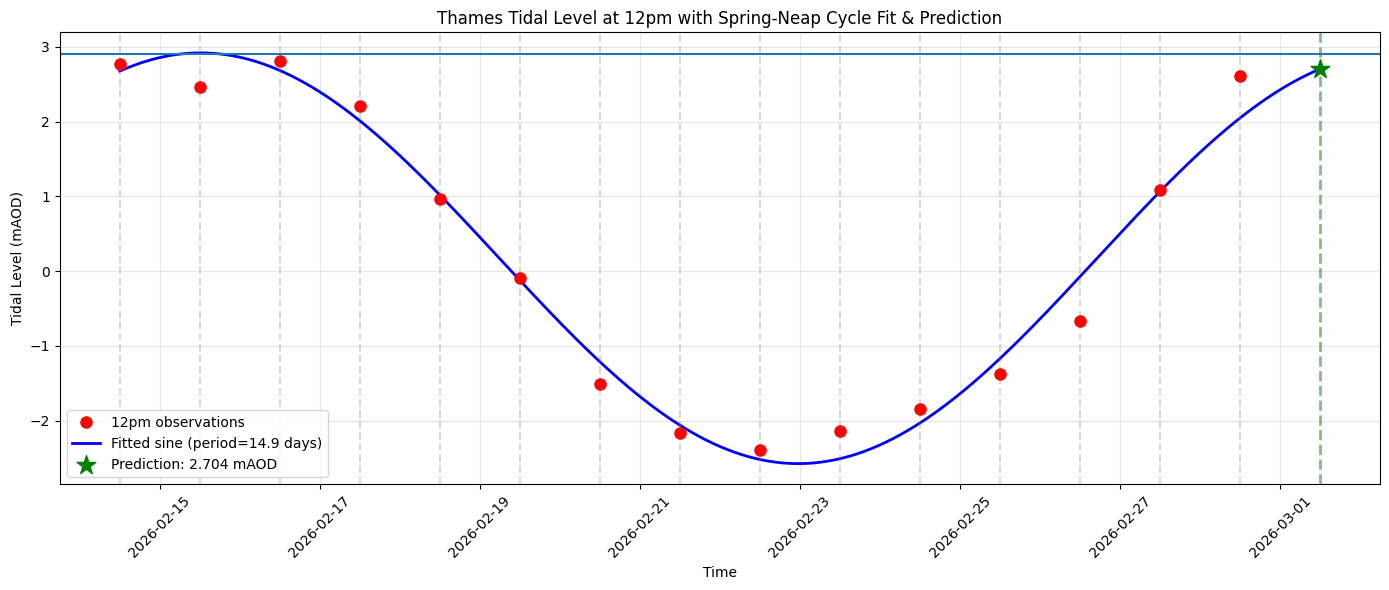

In [14]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
# Cubic spline interpolate and find values at 12pm
df_thames_interp = df_thames.set_index('time').sort_index()
df_thames_interp = df_thames_interp.resample('1min').interpolate(method='cubic')

# Find values at exactly 12pm for each day
noon_values = []
for date in df_thames['time'].dt.date.unique():
    noon = pd.Timestamp(f"{date} 12:00:00").tz_localize("Europe/London")
    if noon in df_thames_interp.index:
        value = df_thames_interp.loc[noon, 'level']
        noon_values.append({'date': date, 'time': noon, 'level': value})
        print(f"{date} at 12pm: {value:.3f} mAOD")

df_noon = pd.DataFrame(noon_values)

# Fit a sine curve to the 12pm values
def tidal_sine(x, amplitude, period, phase, offset):
    return amplitude * np.sin(2 * np.pi / period * (x - phase)) + offset

# Convert times to hours since first reading for fitting
if len(df_noon) > 0:
    x_data = (df_noon['time'] - df_noon['time'].iloc[0]).dt.total_seconds() / 3600
    y_data = df_noon['level'].values
    
    # Initial guess: amplitude ~1m, period ~15 days (360 hours)
    initial_guess = [1.0, 300, 0, 0]
    
    # Constrain period to be at least 15 days (360 hours)
    try:
        params, covariance = curve_fit(
            tidal_sine, x_data, y_data, 
            p0=initial_guess, 
            bounds=([0, 200, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf]),
            maxfev=10000
        )
        amplitude, period, phase, offset = params
        
        print(f"\nFitted sine curve parameters:")
        print(f"  Amplitude: {amplitude:.3f} m")
        print(f"  Period: {period:.2f} hours ({period/24:.1f} days)")
        print(f"  Phase: {phase:.2f} hours ({phase/24:.1f} days)")
        print(f"  Offset: {offset:.3f} mAOD")
        
        # Predict value at March 1, 2026 12pm (Sunday - settlement day)
        target_time = pd.Timestamp("2026-03-01 12:00:00").tz_localize("Europe/London")
        target_x = (target_time - df_noon['time'].iloc[0]).total_seconds() / 3600
        predicted_value = tidal_sine(target_x, *params)
        
        print(f"\n🎯 PREDICTION for 2026-03-01 at 12pm: {predicted_value:.3f} mAOD")
        print(f"   TIDE_SPOT settlement value: {abs(predicted_value * 1000):.0f} mm")
        
        # Generate fitted curve including extrapolation
        x_fit = np.linspace(x_data.min(), target_x, 1000)
        y_fit = tidal_sine(x_fit, *params)
        time_fit = df_noon['time'].iloc[0] + pd.to_timedelta(x_fit, unit='h')
        
        # Plot
        plt.figure(figsize=(14, 6))
        plt.plot(df_noon['time'], df_noon['level'], 'ro', markersize=8, label='12pm observations', zorder=3)
        plt.plot(time_fit, y_fit, 'b-', linewidth=2, label=f'Fitted sine (period={period/24:.1f} days)', zorder=2)
        plt.scatter([target_time], [predicted_value], color='green', s=200, marker='*', 
                   label=f'Prediction: {predicted_value:.3f} mAOD', zorder=4)
        
        # Add vertical lines at 12pm
        for _, row in df_noon.iterrows():
            plt.axvline(x=row['time'], color='gray', linestyle='--', alpha=0.3)
        plt.axvline(x=target_time, color='green', linestyle='--', alpha=0.5, linewidth=2)
        
        plt.xlabel('Time')
        plt.ylabel('Tidal Level (mAOD)')
        plt.title('Thames Tidal Level at 12pm with Spring-Neap Cycle Fit & Prediction')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.axhline(2.9)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Curve fitting failed: {e}")

Settlement (last 24h): 2092.20
Intervals used: 96
                     time  level   diff  put_payoff  call_payoff  strangle
2026-02-27 23:45:00+00:00  2.116 -0.235       0.435          0.0     0.435
2026-02-28 00:00:00+00:00  1.844 -0.272       0.472          0.0     0.472
2026-02-28 00:15:00+00:00  1.570 -0.274       0.474          0.0     0.474
2026-02-28 00:30:00+00:00  1.318 -0.252       0.452          0.0     0.452
2026-02-28 00:45:00+00:00  1.069 -0.249       0.449          0.0     0.449
2026-02-28 01:00:00+00:00  0.820 -0.249       0.449          0.0     0.449
2026-02-28 01:15:00+00:00  0.586 -0.234       0.434          0.0     0.434
2026-02-28 01:30:00+00:00  0.367 -0.219       0.419          0.0     0.419
2026-02-28 01:45:00+00:00  0.148 -0.219       0.419          0.0     0.419
2026-02-28 02:00:00+00:00 -0.064 -0.212       0.412          0.0     0.412
                     time  settlement       date
2026-02-19 12:00:00+00:00      2617.3 2026-02-19
2026-02-20 12:00:00+00:00  

C:\Users\arsen\AppData\Local\Temp\ipykernel_20844\1427281199.py:28: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rolling_settlement = 100.0 * zzt["strangle"].rolling("24H").sum()


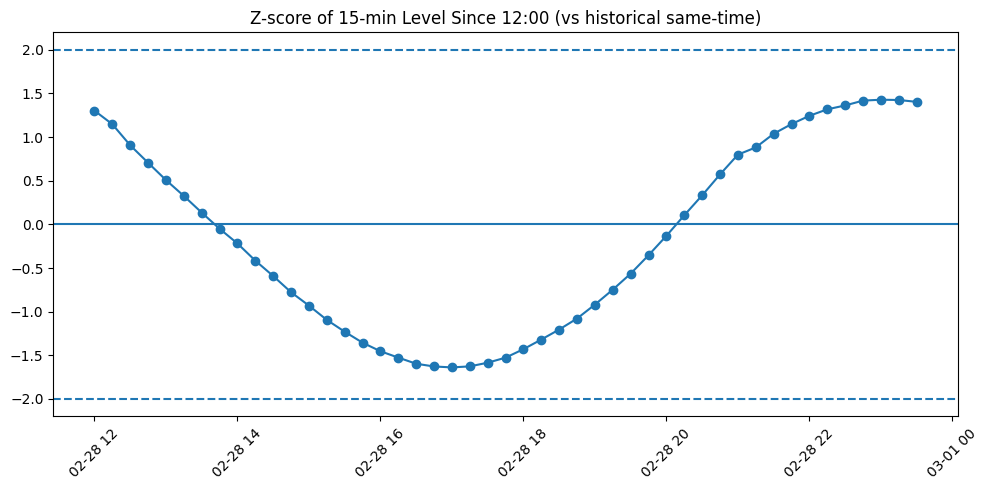

In [15]:
df_thames = get_thames(1450)
zz = df_thames
zz['diff'] = zz['level'].diff()

K_put  = 0.20
K_call = 0.25

zz["put_payoff"]  = np.maximum(0.0, K_put - zz["diff"])
zz["call_payoff"] = np.maximum(0.0, zz["diff"] - K_call)
zz["strangle"]    = zz["put_payoff"] + zz["call_payoff"]

# Use last 24h ending at the most recent timestamp in zz
end = zz["time"].max()
start = end - pd.Timedelta(hours=24)

mask = (zz["time"] > start) & (zz["time"] <= end)  # > start avoids the boundary ambiguity
settlement = 100.0 * zz.loc[mask, "strangle"].sum()

print(f"Settlement (last 24h): {settlement:.2f}")
print(f"Intervals used: {mask.sum()}")

# Optional: show the first few non-zero payoffs
display_cols = ["time", "level", "diff", "put_payoff", "call_payoff", "strangle"]
print(zz.loc[mask & (zz["strangle"] > 0), display_cols].head(10).to_string(index=False))
zzt = zz.set_index("time").sort_index()

# Rolling 24h settlement value (sum over past 24h) * 100
rolling_settlement = 100.0 * zzt["strangle"].rolling("24H").sum()

# Settlement at 12:00 each day (noon)
settle_at_noon = rolling_settlement.at_time("12:00")

# Put into a neat dataframe
daily_noon_settlement = settle_at_noon.rename("settlement").reset_index()
daily_noon_settlement["date"] = daily_noon_settlement["time"].dt.date

print(daily_noon_settlement.tail(10).to_string(index=False))


# Sort + ensure datetime
zz = zz.sort_values("time").copy()
zz["time"] = pd.to_datetime(zz["time"])

# Create date + time-of-day features
zz["date"] = zz["time"].dt.date
zz["tod"] = zz["time"].dt.strftime("%H:%M")

# Identify today
today_date = zz["date"].max()

# Split today (since 12:00) vs historical
today = zz[(zz["date"] == today_date) & (zz["time"].dt.hour >= 12)]
history = zz[zz["date"] < today_date]

# Historical mean/std by clock time
stats = history.groupby("tod")["level"].agg(["mean", "std"])

# Merge stats into today
today = today.merge(stats, left_on="tod", right_index=True, how="left")

# Compute Z-score
today["zscore"] = (today["level"] - today["mean"]) / today["std"]

# Print results
print(today[["time", "level", "zscore"]])

# Plot
plt.figure(figsize=(10,5))
plt.plot(today["time"], today["zscore"], marker="o")
plt.axhline(0)
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Z-score of 15-min Level Since 12:00 (vs historical same-time)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
# Get the last row of df_thames
df_thames.iloc[

{'now': Timestamp('2026-02-28 17:00:00+0000', tz='Europe/London'), 'next_noon': Timestamp('2026-03-01 12:00:00+0000', tz='Europe/London'), 'final_window': (Timestamp('2026-02-28 12:00:00+0000', tz='Europe/London'), Timestamp('2026-03-01 12:00:00+0000', tz='Europe/London')), 'realised_component': np.float64(73.10000000000001), 'expected_remaining_component': np.float64(418.66666666666674), 'expected_settlement': np.float64(491.7666666666667), 'future_slots': 76, 'future_slots_with_history': 76}


In [22]:
def call_payoff(S, K):
    return np.maximum(0.0, S - K)

def put_payoff(S, K):
    return np.maximum(0.0, K - S)

def payoff(S):
    payoff = (
    2 * put_payoff(S, 6200)
    + call_payoff(S, 6200)
    - 2 * call_payoff(S, 6600)
    + 3 * call_payoff(S, 7000)
    )
    return payoff

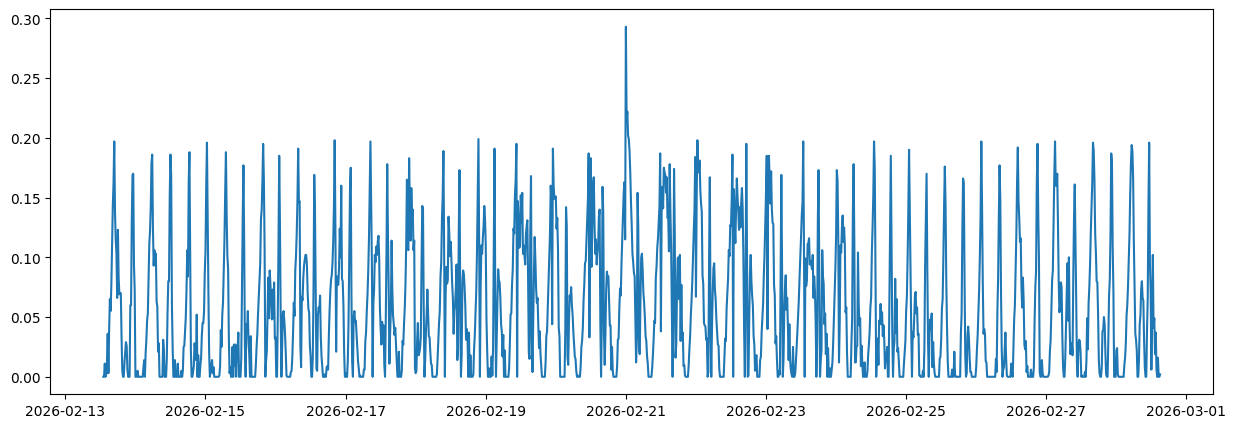

In [24]:
plt.figure(figsize = (15,5))
plt.plot(zz['time'], zz['strangle'])
plt.show()

In [13]:
df_thames

,time,level
0,2026-02-13 12:45:00+00:00,1.299
1,2026-02-13 13:00:00+00:00,1.056
2,2026-02-13 13:15:00+00:00,0.831
3,2026-02-13 13:30:00+00:00,0.642
4,2026-02-13 13:45:00+00:00,0.402
...,...,...
1445,2026-02-28 14:00:00+00:00,0.489
1446,2026-02-28 14:15:00+00:00,0.223
1447,2026-02-28 14:30:00+00:00,-0.007
1448,2026-02-28 14:45:00+00:00,-0.256


In [49]:
# Calculate 15-minute changes in tidal level and compute TIDE_SWING strangle payoff
df_thames = get_thames(1450)
df_thames_sorted = df_thames.sort_values('time').reset_index(drop=True)

# Calculate 15-minute differences
df_thames_sorted['diff_m'] = df_thames_sorted['level'].diff()
df_thames_sorted['diff_cm'] = abs(df_thames_sorted['diff_m'] * 100)

# Strangle payoff: strikes at 20 and 25 cm
df_thames_sorted['put_payoff'] = np.maximum(0, 20 - df_thames_sorted['diff_cm'])
df_thames_sorted['call_payoff'] = np.maximum(0, df_thames_sorted['diff_cm'] - 25)
df_thames_sorted['strangle_payoff'] = df_thames_sorted['put_payoff'] + df_thames_sorted['call_payoff']

# Sum all payoffs for TIDE_SWING settlement
tide_swing_total = df_thames_sorted['strangle_payoff'].sum()

print(f"TIDE_SWING Settlement (sum of strangle payoffs): {tide_swing_total:.1f}")
print(f"\nBreakdown:")
print(f"  Total put payoffs: {df_thames_sorted['put_payoff'].sum():.1f}")
print(f"  Total call payoffs: {df_thames_sorted['call_payoff'].sum():.1f}")
print(f"  15-min intervals with payoff > 0: {(df_thames_sorted['strangle_payoff'] > 0).sum()}")

# Show some example intervals
print(f"\nSample intervals:")
sample = df_thames_sorted[df_thames_sorted['strangle_payoff'] > 0].head(10)
for _, row in sample.iterrows():
    print(f"  {row['time']}: diff={row['diff_cm']:.1f}cm -> put={row['put_payoff']:.1f} + call={row['call_payoff']:.1f} = {row['strangle_payoff']:.1f}")

TIDE_SWING Settlement (sum of strangle payoffs): 8414.4

Breakdown:
  Total put payoffs: 4748.8
  Total call payoffs: 3665.6
  15-min intervals with payoff > 0: 1148

Sample intervals:
  2026-02-13 20:45:00+00:00: diff=27.9cm -> put=0.0 + call=2.9 = 2.9
  2026-02-13 21:00:00+00:00: diff=27.6cm -> put=0.0 + call=2.6 = 2.6
  2026-02-13 21:15:00+00:00: diff=25.6cm -> put=0.0 + call=0.6 = 0.6
  2026-02-13 22:15:00+00:00: diff=14.0cm -> put=6.0 + call=0.0 = 6.0
  2026-02-13 22:30:00+00:00: diff=14.0cm -> put=6.0 + call=0.0 = 6.0
  2026-02-13 22:45:00+00:00: diff=7.0cm -> put=13.0 + call=0.0 = 13.0
  2026-02-13 23:00:00+00:00: diff=3.1cm -> put=16.9 + call=0.0 = 16.9
  2026-02-13 23:15:00+00:00: diff=3.0cm -> put=17.0 + call=0.0 = 17.0
  2026-02-13 23:30:00+00:00: diff=10.6cm -> put=9.4 + call=0.0 = 9.4
  2026-02-13 23:45:00+00:00: diff=12.8cm -> put=7.2 + call=0.0 = 7.2


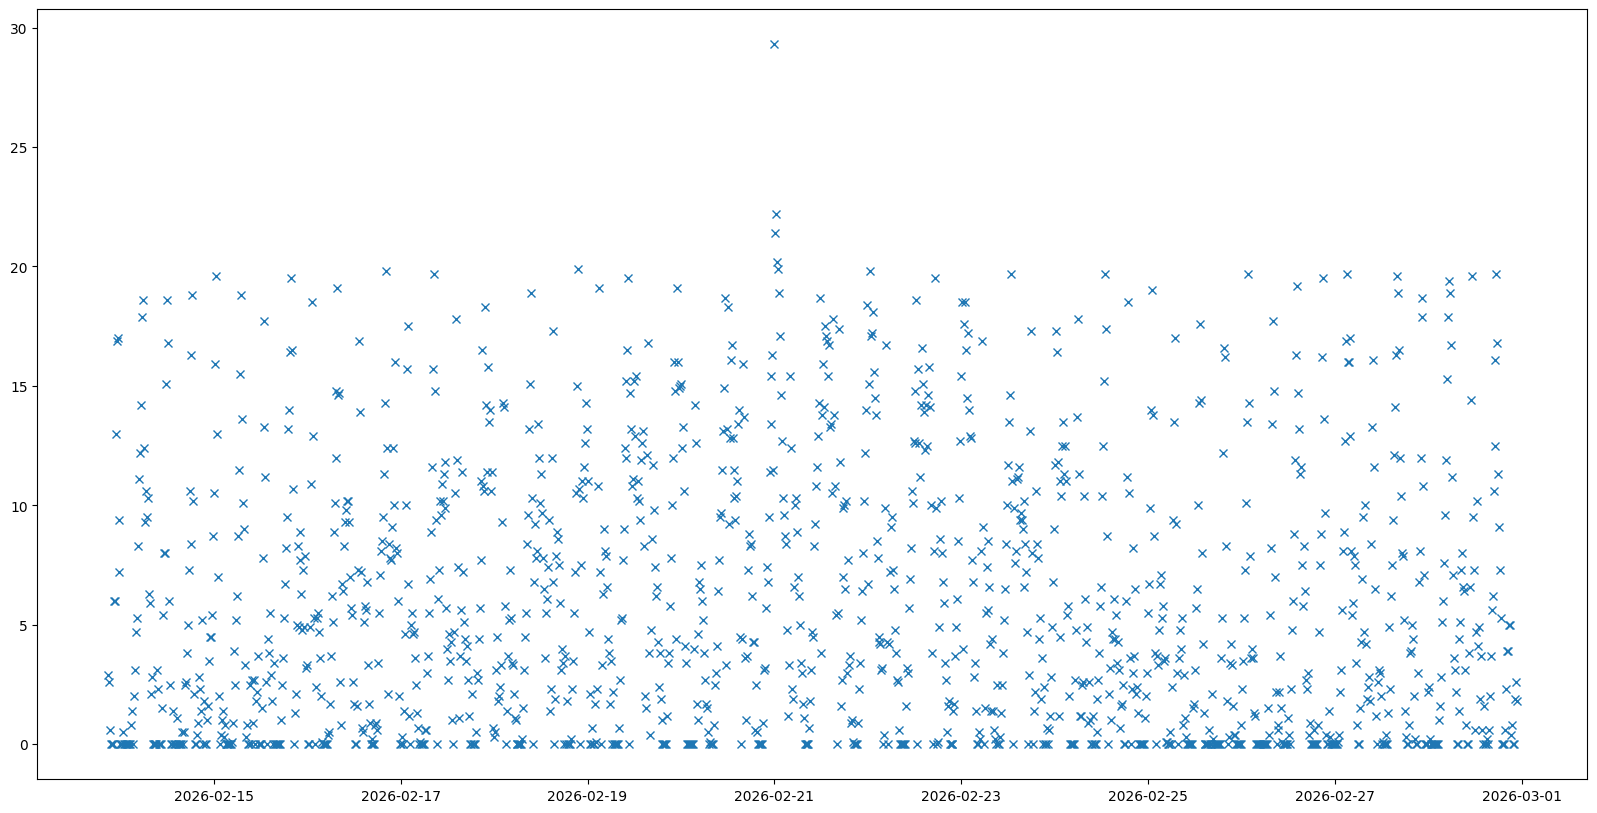

In [50]:
plt.figure(figsize = (20, 10))
plt.plot(df_thames_sorted['time'], df_thames_sorted['strangle_payoff'],'x')

In [19]:
df = df_thames.sort_values("time").reset_index(drop=True).copy()

# 15-min absolute difference in metres
df["diff_m"] = df["level"].diff().abs().fillna(0.0)

K_put = 0.20
K_call = 0.25

df["put_payoff"]  = np.maximum(0.0, K_put - df["diff_m"])
df["call_payoff"] = np.maximum(0.0, df["diff_m"] - K_call)
df["strangle_value"] = df["put_payoff"] + df["call_payoff"]

tide_swing_settlement = 100.0 * df["strangle_value"].sum()

print(f"TIDE_SWING settlement: {tide_swing_settlement:.2f}")

TIDE_SWING settlement: 8455.00
